In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path('/content/drive/MyDrive') # change path here!

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [3]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

# Wnioski z EDA

## Czyszczenie zbioru danych

Kolumn takich jak Name, Ticket i Cabin można się pozbyć. W przypadku Name i Ticket są to zbędne identyfikatory bez wartości statystyznej, natomiast Cabin w zdecydowanej większości (ponad 70%) to brakujące wartości.

Brakujące wartości w Age i Fare zastępujemy medianą. W przypadku Embarked można użyć mody ze względu na fakt bardzo małej liczby brakujących danych.

Dodałem dwie przydatne kolumny sprawdzające czy pasażer był dzieckiem (isChild) oraz ilu miał w sumie członków rodziny na pokładzie (FamilySize).

Zmieniłem też typy niektórych danych takich jak Sex oraz Pclass na typ category.

Na koniec zakodowałem zmienne Sex, isChild oraz Embarked. Zakodowanie zmiennych przy pomocy cyfr znacznie ułatwia naukę modelu.

## Wnioski na podstawie zbioru danych

Największy wpływ na przeżywalność miała płeć, klasa biletu oraz koszt biletu. Najczęściej przeżywały kobiety i osoby z pierwszej klasy, a więc z najwyższym kosztem biletu. Dzieci także przeżywały nieco częściej od dorosłych.

In [4]:
# Usuwanie zbędnych kolumn
titanic_df = titanic_df.drop(columns=["Name", "Ticket", "Cabin"]) # zmienne Name oraz Ticket, stanowiące odpowiednio
                                                                  # imię oraz identyfikator biletu także można usunąć
# Uzupełnianie braków
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Fare"] = titanic_df["Fare"].fillna(titanic_df["Fare"].median())

# Dodanie przydatnych kolumn
titanic_df["isChild"] = titanic_df["Age"] < 18
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df['Parch'] + 1

# Zmiana typów
titanic_df["Embarked"] = titanic_df["Embarked"].astype("category")
titanic_df["Sex"] = titanic_df["Sex"].astype("category")
titanic_df["isChild"] = titanic_df["isChild"].astype("category")
titanic_df["Pclass"] = pd.Categorical(titanic_df["Pclass"], categories=[1, 2, 3], ordered=True)

# Kodowanie danych
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
titanic_df['isChild'] = titanic_df['isChild'].astype(int)

titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True, dtype=int) #one-hot encoding dla zmiennej Embarked
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,isChild,FamilySize,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,0,2,0,1
2,1,1,1,38.0,1,0,71.2833,0,2,0,0
3,1,3,1,26.0,0,0,7.9250,0,1,0,1
4,1,1,1,35.0,1,0,53.1000,0,2,0,1
5,0,3,0,35.0,0,0,8.0500,0,1,0,1


# Trenowanie i testowanie modeli

In [45]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

X = titanic_df.drop(columns="Survived")
y = titanic_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=31, stratify=y) # podział danych na testowe i treningowe

## Baseline (wykorzystanie Dummy Classifiera)

In [46]:
dummy = DummyClassifier(strategy="most_frequent") # przewiduje zawsze najczęstszą klasę (śmierć)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print("Dummy Accuracy:", dummy.score(X_test, y_test))

Dummy Accuracy: 0.6145251396648045


## Drzewo decyzyjne

### Kroswalidacja

In [47]:
model_tree = DecisionTreeClassifier(max_depth=3)
wyniki = cross_val_score(model_tree, X, y, cv=5, scoring='accuracy')

print(wyniki)
print(f"srednia: {wyniki.mean():.3f}  odchylenie: {wyniki.std():.3f}")

[0.79329609 0.82022472 0.81460674 0.78089888 0.84269663]
srednia: 0.810  odchylenie: 0.022


### Trenowanie i testowanie drzewa decyzyjnego

In [48]:
model_tree = DecisionTreeClassifier(max_depth=3)
# trenowanie modelu
model_tree.fit(X_train, y_train)

# predykcje
y_train_pred = model_tree.predict(X_train)
y_test_pred = model_tree.predict(X_test)

print("> Na zbiorze treningowym:\n")
print(classification_report(y_train, y_train_pred))
print(confusion_matrix(y_train, y_train_pred))

print("> Na zbiorze testowym:\n")
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

> Na zbiorze treningowym:

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       439
           1       0.83      0.72      0.77       273

    accuracy                           0.84       712
   macro avg       0.83      0.81      0.82       712
weighted avg       0.84      0.84      0.83       712

[[398  41]
 [ 76 197]]
> Na zbiorze testowym:

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

[[95 15]
 [19 50]]


### Badanie hiperparametrów

Badanie hiperparametru max_depth

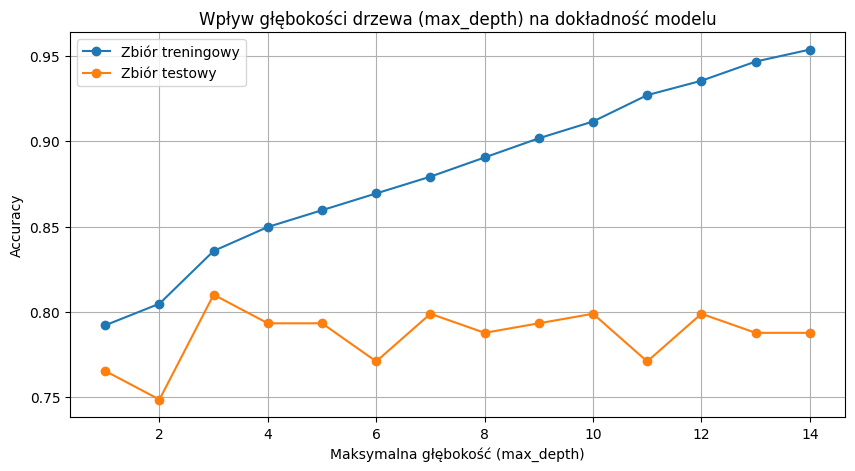

In [89]:
train_scores_tree = []
test_scores_tree = []
depths = range(1, 15)

for d in depths:
    clf_tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf_tree.fit(X_train, y_train)

    # Ocena na treningowym i testowym
    train_scores_tree.append(accuracy_score(y_train, clf_tree.predict(X_train)))
    test_scores_tree.append(accuracy_score(y_test, clf_tree.predict(X_test)))

# Wizualizacja
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores_tree, label='Zbiór treningowy', marker='o')
plt.plot(depths, test_scores_tree, label='Zbiór testowy', marker='o')
plt.title('Wpływ głębokości drzewa (max_depth) na dokładność modelu')
plt.xlabel('Maksymalna głębokość (max_depth)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Badanie hiperparametru min_samples_leaf

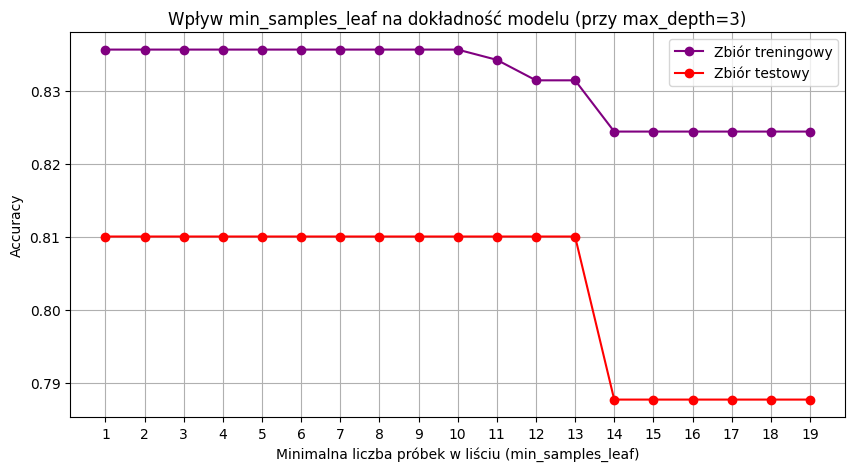

In [90]:
train_scores_leaf = []
test_scores_leaf = []
leaf_range = range(1, 20)

for l in leaf_range:
    # max_depth ustawiamy na najlepsze 3, a badamy min_samples_leaf
    clf_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=l, random_state=42)
    clf_tree.fit(X_train, y_train)

    train_scores_leaf.append(accuracy_score(y_train, clf_tree.predict(X_train)))
    test_scores_leaf.append(accuracy_score(y_test, clf_tree.predict(X_test)))

# Wizualizacja
plt.figure(figsize=(10, 5))
plt.plot(leaf_range, train_scores_leaf, label='Zbiór treningowy', marker='o', color='purple')
plt.plot(leaf_range, test_scores_leaf, label='Zbiór testowy', marker='o', color='red')
plt.title('Wpływ min_samples_leaf na dokładność modelu (przy max_depth=3)')
plt.xlabel('Minimalna liczba próbek w liściu (min_samples_leaf)')
plt.ylabel('Accuracy')
plt.xticks(leaf_range)
plt.legend()
plt.grid(True)
plt.show()

### Wnioski z pierwszego modelu (drzewo decyzyjne):
- Jak widać, model osiąga znacznie lepsze rezultaty od baseline'u wyznaczonego przez DummyClassifier. Podczas gdy dummy osiąga dokładność około 61,5%, model osiąga dokładność 81% na zbiorze testowym.
- Model osiąga nieco lepsze rezultaty na zbiorze treningowym (dokładność 84%) niż na testowym (81%), co jest oczekiwanym rezultatem.
- Kroswalidacja wkazała na małe odchylenie standardowe, co oznacza że model jest stabilny i regularnie uzyskuje rezultaty bliskie średniemu 81%.
- Jak widać, po zbadaniu różnych wartości hiperparametru max_depth, najlepsze rezulaty oferuje założona na początku głębokość równa 3 - dokładność na zbiorze testowym jest wtedy najlepsza i najbliższa tej na zbiorze treningowym. Później dokładność na zbiorze testowym spada, a na treningowym dąży coraz bliżej 1, co jest klasycznym objawem przetrenowania.
- Badanie hiperparametru min_samples_leaf wykazało, że dla wartości równej 13 lub większej następuje gwałtowny spadek dokładności zarówno dla zbioru treningowego jak i testowego.
- Sama dokładność (Accuracy) to za mało, jeśli zależy nam na wyłapaniu jak największej liczby ocalałych. Dlatego warto spojrzeć również na metrykę Recall dla klasy 1 oraz F1-score, który stanowi kompromis pomiędzy czułością a precyzją.

## Metoda najbliższych sąsiadów (KNN)

### Standaryzacja danych
Dla drzewa decyzyjnego nie było potrzeby standaryzować dane. Dla KNN jest to już konieczne.

In [64]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Kroswalidacja

In [80]:
from sklearn.pipeline import make_pipeline

# pipeline - konieczne w standaryzacji
pipeline_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=9))

wyniki = cross_val_score(pipeline_knn, X, y, cv=5, scoring='accuracy')

print(wyniki)
print(f"srednia: {wyniki.mean():.3f}  odchylenie: {wyniki.std():.3f}")

[0.82122905 0.78089888 0.80337079 0.79213483 0.82022472]
srednia: 0.804  odchylenie: 0.016


### Trenowanie i testowanie KNN

In [75]:
model_knn = KNeighborsClassifier(n_neighbors=9)

# trenowanie modelu
model_knn.fit(X_train_scaled, y_train)

# predykcje
y_train_pred_knn = model_knn.predict(X_train_scaled)
y_test_pred_knn = model_knn.predict(X_test_scaled)

print("> KNN na zbiorze treningowym:\n")
print(classification_report(y_train, y_train_pred_knn))
print(confusion_matrix(y_train, y_train_pred_knn))

print("> KNN na zbiorze testowym:\n")
print(classification_report(y_test, y_test_pred_knn))
print(confusion_matrix(y_test, y_test_pred_knn))

> KNN na zbiorze treningowym:

              precision    recall  f1-score   support

           0       0.84      0.91      0.88       439
           1       0.84      0.73      0.78       273

    accuracy                           0.84       712
   macro avg       0.84      0.82      0.83       712
weighted avg       0.84      0.84      0.84       712

[[401  38]
 [ 75 198]]
> KNN na zbiorze testowym:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       110
           1       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179

[[98 12]
 [17 52]]


### Badanie hiperparametrów

Badanie hiperparametru n_neighbors


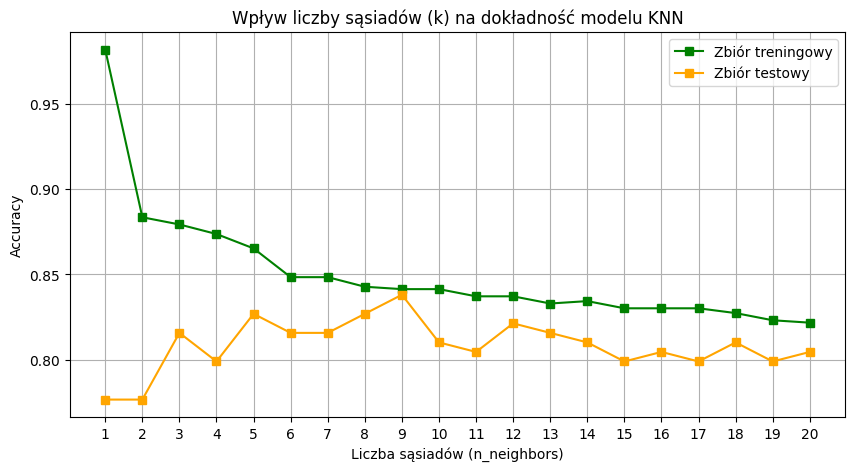

In [72]:
train_scores_knn = []
test_scores_knn = []
neighbors_range = range(1, 21)

for k in neighbors_range:
    clf_knn = KNeighborsClassifier(n_neighbors=k)
    clf_knn.fit(X_train_scaled, y_train)

    # Ocena na treningowym i testowym
    train_scores_knn.append(accuracy_score(y_train, clf_knn.predict(X_train_scaled)))
    test_scores_knn.append(accuracy_score(y_test, clf_knn.predict(X_test_scaled)))

# Wizualizacja
plt.figure(figsize=(10, 5))
plt.plot(neighbors_range, train_scores_knn, label='Zbiór treningowy', marker='s', color='green')
plt.plot(neighbors_range, test_scores_knn, label='Zbiór testowy', marker='s', color='orange')
plt.title('Wpływ liczby sąsiadów (k) na dokładność modelu KNN')
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range)
plt.legend()
plt.grid(True)
plt.show()

Badanie metryk: Euklidesowskiej i Manhattan

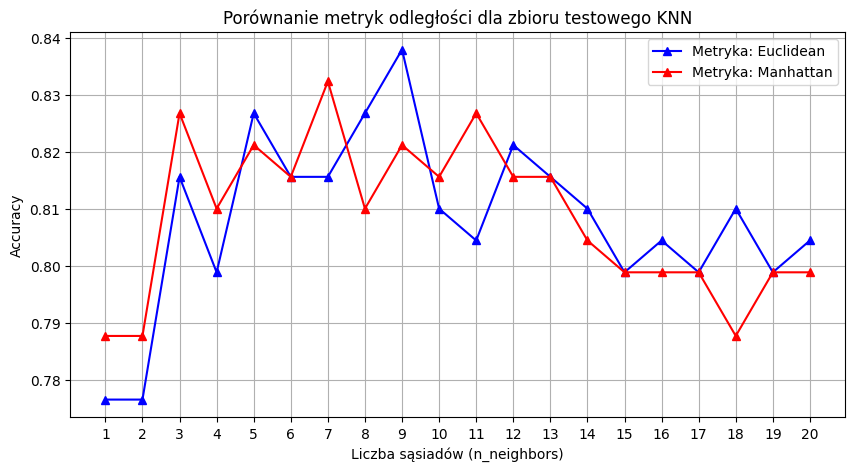

In [94]:
test_scores_euclidean = []
test_scores_manhattan = []
neighbors_range = range(1, 21)

for k in neighbors_range:
    # KNN z metryką Euklidesową
    clf_euc = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    clf_euc.fit(X_train_scaled, y_train)
    test_scores_euclidean.append(accuracy_score(y_test, clf_euc.predict(X_test_scaled)))

    # KNN z metryką Manhattan
    clf_man = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    clf_man.fit(X_train_scaled, y_train)
    test_scores_manhattan.append(accuracy_score(y_test, clf_man.predict(X_test_scaled)))

# Wizualizacja
plt.figure(figsize=(10, 5))
plt.plot(neighbors_range, test_scores_euclidean, label='Metryka: Euclidean', marker='^', color='blue')
plt.plot(neighbors_range, test_scores_manhattan, label='Metryka: Manhattan', marker='^', color='red')
plt.title('Porównanie metryk odległości dla zbioru testowego KNN')
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range)
plt.legend()
plt.grid(True)
plt.show()

### Wnioski z drugiego modelu (KNN):
- Jak widać, podobnie jak w przypadku drzewa, model osiąga znacznie lepsze rezultaty od baseline'u wyznaczonego przez DummyClassifier. Podczas gdy dummy osiąga dokładność około 61,5%, model osiąga dokładność 84% na zbiorze testowym.
- Model osiąga bardzo podobne rezultaty zarówno dla zbioru treningowego jak i testowego. Dla obu dokładność wynosi 84%.
- Kroswalidacja wkazała na małe odchylenie standardowe, co oznacza że model jest stabilny i regularnie uzyskuje rezultaty bliskie średniemu 80%.
- Jak widać, po zbadaniu różnych wartości hiperparametru n_neighbors, najlepsze rezulaty oferuje założona na początku liczba sąsiadów równa 9 - dokładność na zbiorze testowym jest wtedy najlepsza i najbliższa tej na zbiorze treningowym. Później dokładność na zbiorze testowym spada, podobnie zresztą jak na zbiorze treningowym.
- Dla optymalnej liczby sąsiadów (równej 9) lepsza okazała się metryka euklidesowa od odległości manhattan.
- Sama dokładność (Accuracy) to za mało, jeśli zależy nam na wyłapaniu jak największej liczby ocalałych. Dlatego warto spojrzeć również na metrykę Recall dla klasy 1 oraz F1-score, który stanowi kompromis pomiędzy czułością a precyzją.
- Co ciekawe metoda najbliższych sąsiadów dała lepsze rezultaty niż drzewo decyzyjne. Najlepszy rezultat (dokładność) dla drzewa to 81%, podczas gdy dla KNN jest to 84%.

# Wnioski z zadania
- Zadanie to pokazało mi jak w praktyce wygląda szkolenie i testowanie różnych modeli uczenia maszynowego.
- Dla ofiar tytanika metoda KNN dała lepsze rezultaty niż drzewo decyzyjne, ale oba modele zaprezentowały się znacznie lepiej od baseline'u (dummy classifier).